# **Workshop: Distant Viewing - Computational Analysis of Cultural Heritage Images**

# Section 01: The Europeana API 💁🛎️


| Section | Topic |
|---------|-------|
| **1** | Europeana API — browse 50M+ cultural heritage items by country, institution, and keyword |
| **2** | Download a collection — bulk download images from a museum |
| **3** | Semantic text search with CLIP — find artworks using natural language |
| **4** | Image similarity search — find artworks visually similar to a query image |

## ***Setup***

mount google drive 🪛

In [ ]:
# @title
# Mount Google Drive
# If already mounted this will show "Drive is already mounted" — that's fine.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Add shortcut to the project folder 📁 to your Google drive

In [ ]:
# @title
# Add shared folder shortcut to My Drive
from google.colab import auth
from googleapiclient.discovery import build
import re

# Authenticate
auth.authenticate_user()
drive_service = build('drive', 'v3')

# ============================================================
# PASTE YOUR SHARED FOLDER LINK HERE
# ============================================================
SHARED_FOLDER_LINK = 'https://drive.google.com/drive/folders/17AEmw7IHIt-kjWDGoLrx0KAioDID_09v?usp=drive_link'
SHORTCUT_NAME = 'Distant_viewing'  # Name for the shortcut in your Drive
# ============================================================

# Extract folder ID from link
match = re.search(r'/folders/([a-zA-Z0-9_-]+)', SHARED_FOLDER_LINK)
if not match:
    raise ValueError('Could not extract folder ID from link')
folder_id = match.group(1)

# Check if shortcut already exists
existing = drive_service.files().list(
    q=f"name='{SHORTCUT_NAME}' and mimeType='application/vnd.google-apps.shortcut' and trashed=false",
    spaces='drive',
    fields='files(id, name)'
).execute().get('files', [])

if existing:
    print(f'✓ Shortcut "{SHORTCUT_NAME}" already exists in My Drive')
else:
    # Create shortcut to the shared folder
    shortcut_metadata = {
        'name': SHORTCUT_NAME,
        'mimeType': 'application/vnd.google-apps.shortcut',
        'shortcutDetails': {
            'targetId': folder_id
        }
    }

    shortcut = drive_service.files().create(
        body=shortcut_metadata,
        fields='id, name, shortcutDetails'
    ).execute()

    print(f'✓ Created shortcut "{SHORTCUT_NAME}" in My Drive')
    print(f'  Target folder ID: {shortcut["shortcutDetails"]["targetId"]}')

print(f'\n📁 You can now access the folder at: /content/drive/MyDrive/{SHORTCUT_NAME}/')


✓ Shortcut "Distant_viewing" already exists in My Drive

📁 You can now access the folder at: /content/drive/MyDrive/Distant_viewing/


### Install & Imports

In [ ]:
# @title
# Uncomment and run in Google Colab (torch is already installed there, only CLIP is needed)
# Install packages that are not pre-installed in Colab
# (torch, torchvision, numpy, Pillow, requests are already available)
!pip install -q git+https://github.com/openai/CLIP.git ftfy
!pip install -q requests Pillow numpy ipywidgets
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 27.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# @title
import io
import json
import time
from pathlib import Path
from collections import Counter

import numpy as np
import requests
from PIL import Image as PILImage
from IPython.display import display, Image, HTML
import ipywidgets as widgets

try:
    import torch
    import clip
    CLIP_AVAILABLE = True
    print('✓ CLIP loaded successfully!')
except ImportError:
    CLIP_AVAILABLE = False
    print('⚠️ CLIP not available — install it first (see install cell above)')

if CLIP_AVAILABLE:
    if torch.cuda.is_available():
        DEVICE = 'cuda'
        print(f'✓ GPU (CUDA): {torch.cuda.get_device_name(0)}')
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        DEVICE = 'mps'
        print('✓ Apple Silicon GPU (MPS)')
    else:
        DEVICE = 'cpu'
        print('ℹ️ No GPU — using CPU')

✓ CLIP loaded successfully!
✓ GPU (CUDA): Tesla T4


### Directories configuration

In [ ]:
# @title
PROJECT_ROOT = Path("drive/MyDrive/Distant_viewing")
NOTEBOOK_DIR = PROJECT_ROOT

DATA_DIR   = PROJECT_ROOT / 'data'
IMAGES_DIR = DATA_DIR / 'images'
MODELS_DIR = PROJECT_ROOT / 'models' / 'CLIP'

print(f'Project root : {PROJECT_ROOT}')
print(f'Data dir     : {DATA_DIR}')
print(f'Models dir   : {MODELS_DIR}')

Project root : drive/MyDrive/Distant_viewing
Data dir     : drive/MyDrive/Distant_viewing/data
Models dir   : drive/MyDrive/Distant_viewing/models/CLIP


---

## ***Section 1: Working with Cultural Heritage APIs (Europeana)***

[Europeana](https://www.europeana.eu/) is Europe's digital platform for cultural heritage:
- **50+ million** digitized items from European museums, galleries, libraries and archives
- **3,000+** contributing institutions across Europe
- Collections: artworks, books, music, videos, photographs, manuscripts
- Open data under various Creative Commons licenses

### What is an API?

**API** stands for **Application Programming Interface**. It:
- Takes your **request** ("give me all paintings by Rembrandt")
- Sends it to a **server** (the database)
- Returns a **response** (the data you asked for)

### Why APIs matter for Digital Humanities

| Benefit | Description |
|---------|-------------|
| **Scale** | Download thousands of records automatically instead of clicking through web pages |
| **Structure** | Data comes in machine-readable formats (JSON, XML) ready for analysis |
| **Reproducibility** | Your code documents exactly how you obtained your data |
| **Integration** | Combine data from multiple institutions |

### Common Data Formats

| Format | Description | Example |
|--------|-------------|---------|
| **JSON** | JavaScript Object Notation — human-readable, widely used | `{"name": "Mona Lisa", "year": 1503}` |
| **XML** | eXtensible Markup Language | `<artwork><name>Mona Lisa</name></artwork>` |
| **CSV** | Comma-Separated Values — spreadsheet-like | `name,year\nMona Lisa,1503` |

### How an API Works

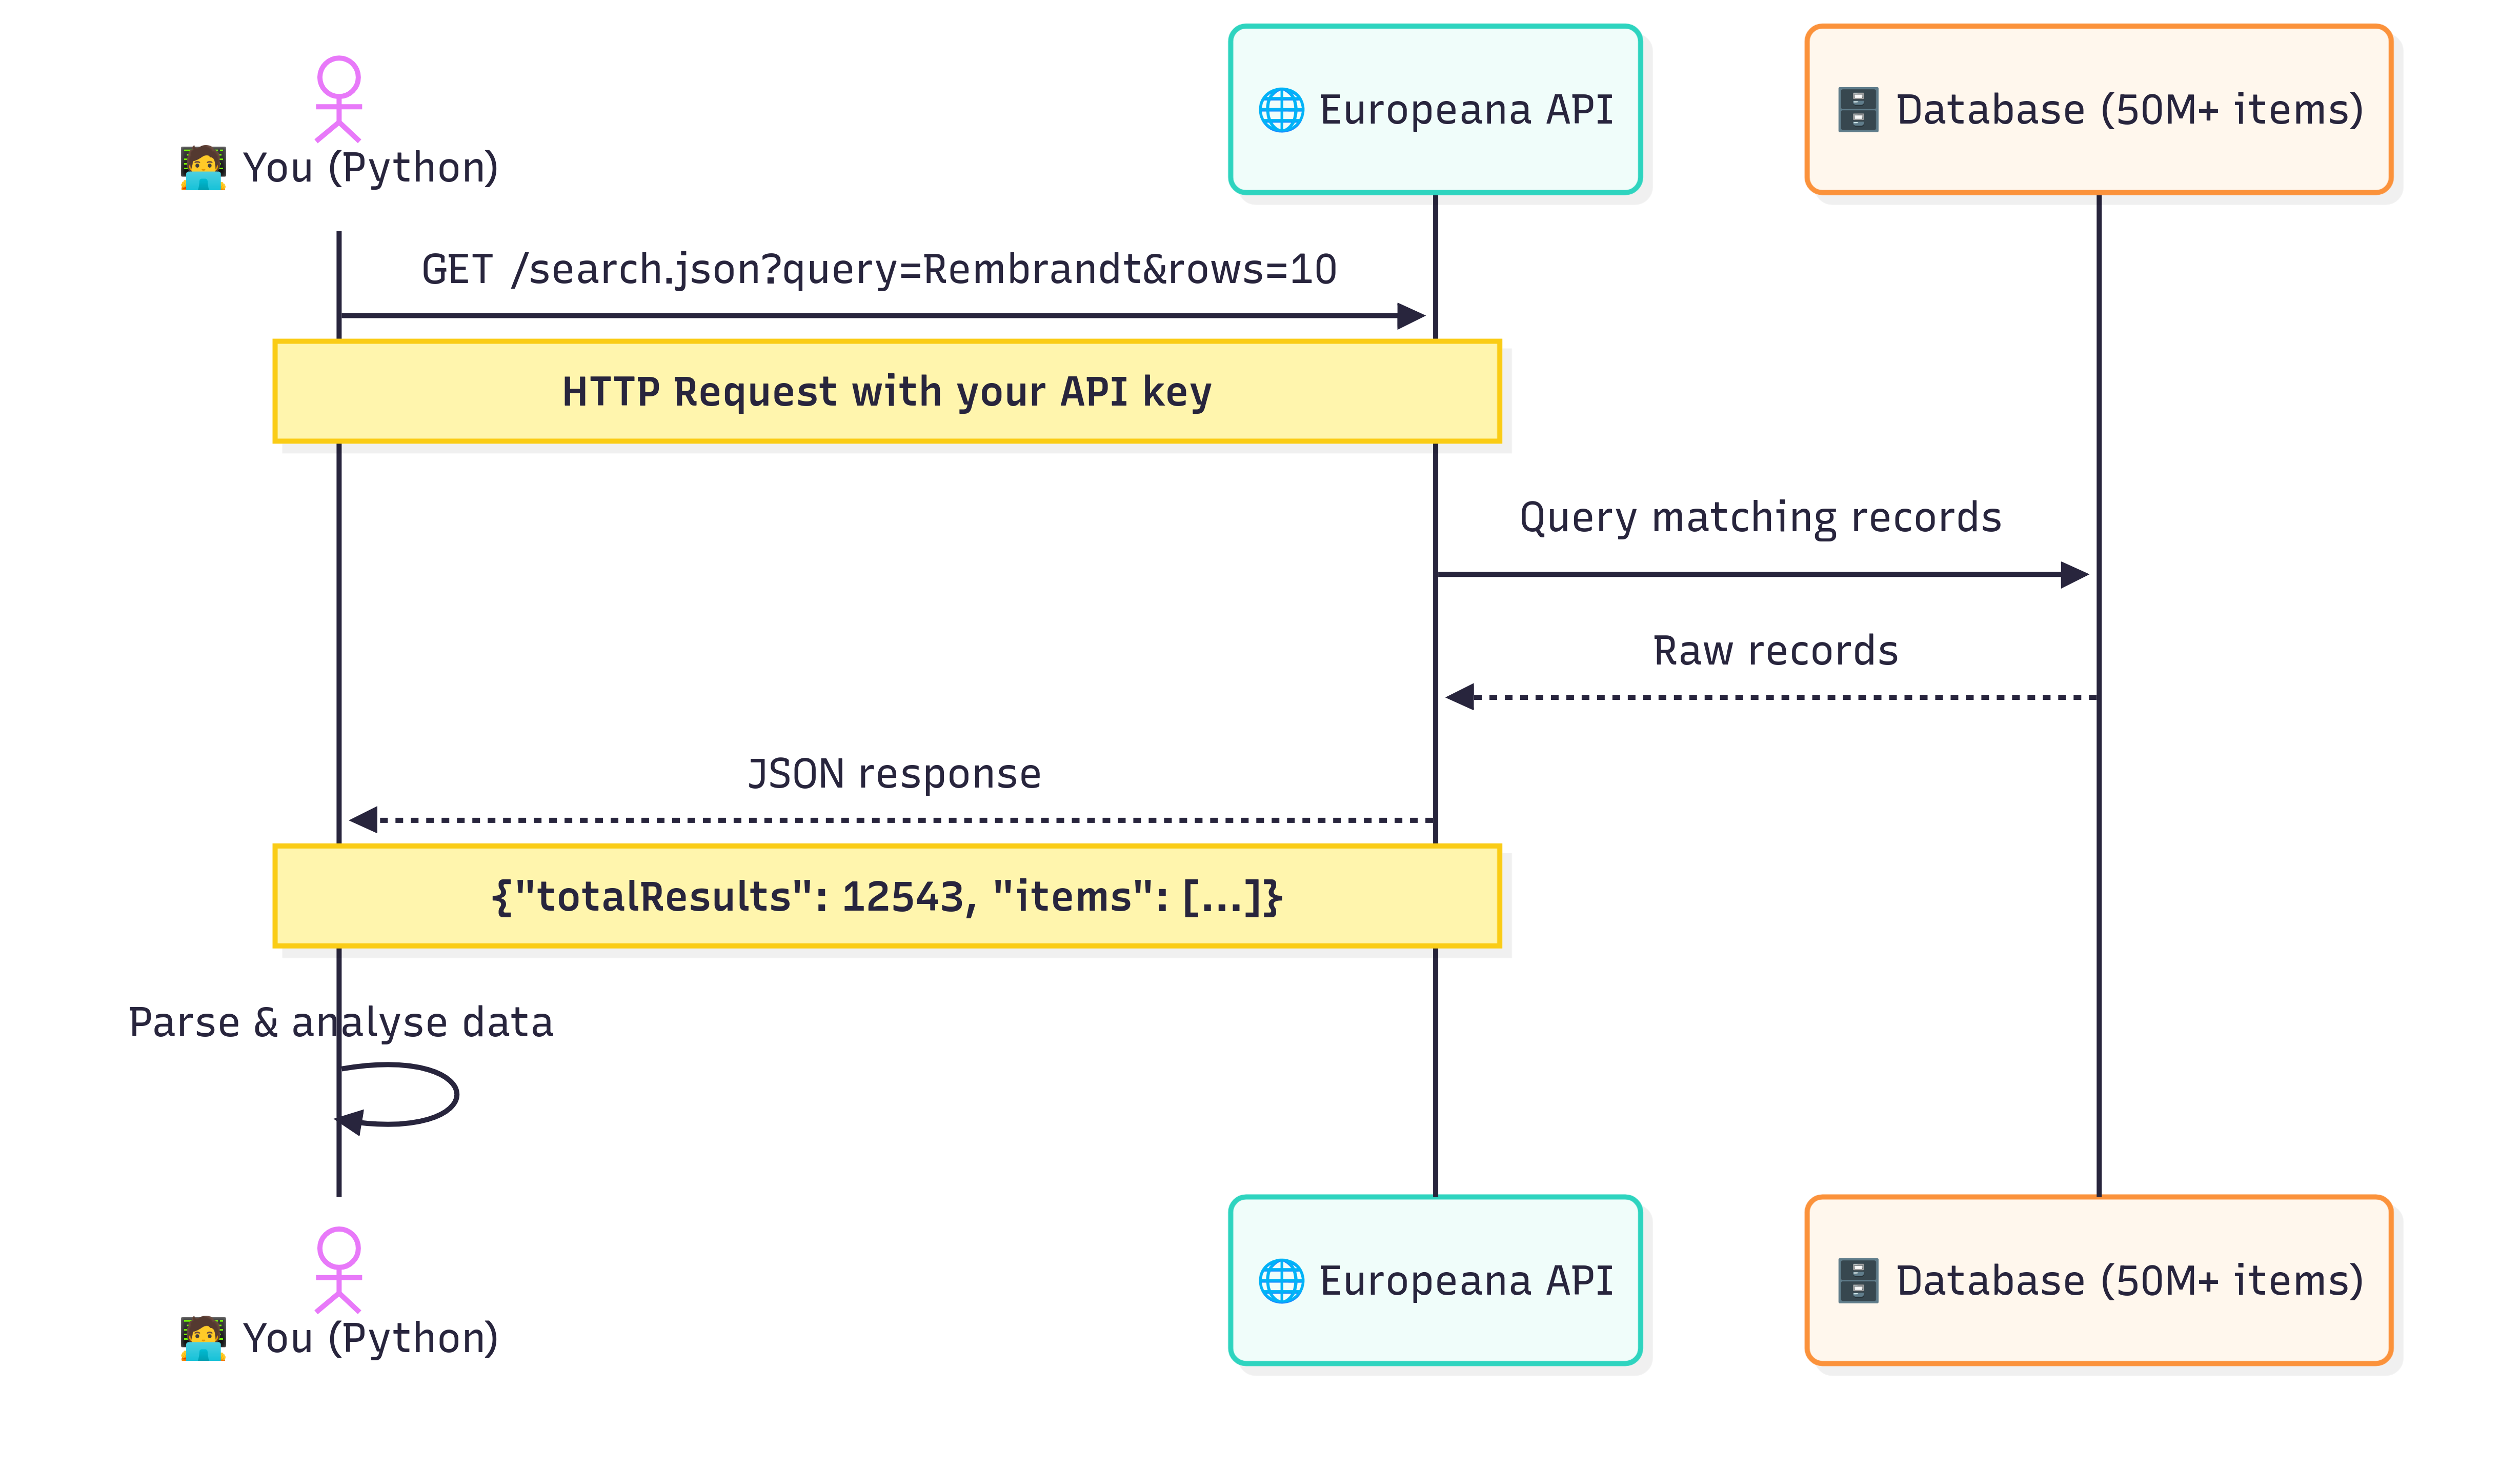

> **Key idea:** You never talk to the database directly — the API is a controlled gateway that handles authentication, rate limiting, and formats the data for you.

## Understanding the Europeana API

### Key Search Parameters

| Parameter | Description | Example |
|-----------|-------------|---------|
| `query` | Search term | `Rembrandt`, `painting`, `*` (all) |
| `qf` | Query filter | `TYPE:IMAGE`, `COUNTRY:Netherlands` |
| `theme` | Thematic collection | `art`, `fashion`, `photography`, `music` |
| `reusability` | License filter | `open`, `restricted`, `permission` |
| `rows` | Results per page (max 100) | `12` (default), `100` |
| `profile` | Detail level | `standard`, `rich`, `facets` |

### Available Themes

| Theme | Description |
|-------|-------------|
| `art` | Paintings, sculptures, and visual art |
| `photography` | Historical and contemporary photographs |
| `fashion` | Clothing, accessories, and fashion design |
| `music` | Musical scores, recordings, and instruments |
| `newspapers` | Historical newspapers and periodicals |
| `nature` | Natural history specimens and illustrations |
| `ww1` | World War I collections |
| `archaeology` | Archaeological artifacts and sites |

### What is a Facet?

A **facet** is a category used to filter and aggregate search results — like a filter dimension in a search interface:
- `COUNTRY` — how many results per country
- `DATA_PROVIDER` — counts by institution/museum
- `TYPE` — counts by media type (image, video, text, etc.)
- `dc_creator` — counts by creator/artist

## API Key

Europeana requires a free API key:
1. Visit: https://pro.europeana.eu/page/get-api
2. Register and request a key
3. Save it to `notebooks/api-key-europeana.txt`

The demo key below works for testing (limited to 999 requests/day).

#### load api key below...

In [ ]:
# @title
API_KEY = 'api2demo'  # demo key — get your own at https://pro.europeana.eu/page/get-api

key_locations = [
    NOTEBOOK_DIR / 'api-key-europeana.txt',
    PROJECT_ROOT / 'misc' / 'api-key-europeana.txt',
    PROJECT_ROOT / 'api-key-europeana.txt',
]

for key_file in key_locations:
    if key_file.exists():
        custom = key_file.read_text().strip()
        if custom and custom != 'api2demo':
            API_KEY = custom
            print(f'✓ API key loaded from {key_file}')
            break
else:
    print('ℹ️ Using demo API key (999 requests/day)')
    print('  Get your own key: https://pro.europeana.eu/page/get-api')

BASE_URL = 'https://api.europeana.eu/record/v2'
print(f'API endpoint: {BASE_URL}')

ℹ️ Using demo API key (999 requests/day)
  Get your own key: https://pro.europeana.eu/page/get-api
API endpoint: https://api.europeana.eu/record/v2


## Exploring the Europeana Collection

Let's start by discovering what countries and institutions are available in Europeana using **facets**.

In [ ]:
# @title
def get_facet_values(facet_name, query='*', qf=None, max_values=50, theme=None):
    """
    Query the Europeana API to get available values for a facet.

    Parameters:
        facet_name: The facet to query (e.g., 'COUNTRY', 'DATA_PROVIDER', 'proxy_dc_creator')
        query:      Search query to filter results (default: '*' for all)
        qf:         Optional query filters as list
        max_values: Maximum number of facet values to return
        theme:      Optional thematic collection filter

    Returns:
        List of (value, count) tuples
    """
    params = {
        'wskey': API_KEY,
        'query': query,
        'rows': 0,
        'profile': 'facets',
        'facet': facet_name,
        f'f.{facet_name}.facet.limit': max_values,
    }
    if qf:
        params['qf'] = qf
    if theme:
        params['theme'] = theme

    try:
        resp = requests.get(f'{BASE_URL}/search.json', params=params, timeout=30)
        resp.raise_for_status()
        for facet in resp.json().get('facets', []):
            if facet.get('name') == facet_name:
                return [(f['label'], f['count']) for f in facet.get('fields', [])]
        return []
    except requests.exceptions.RequestException as e:
        print(f'❌ Error: {e}')
        return []

### Countries

In [ ]:
countries = get_facet_values('COUNTRY', max_values=50)
country_counts = {c: n for c, n in countries}

In [ ]:
# @title
for country, count in countries:
    print(f'  {country:<30} ({count:,} items)')

print('Available COUNTRIES in Europeana:')
print('=' * 60)

print(f'\nTotal countries: {len(countries)}')

  Netherlands                    (8,845,226 items)
  Germany                        (7,757,624 items)
  Spain                          (6,416,456 items)
  Sweden                         (6,083,438 items)
  United Kingdom                 (5,669,073 items)
  France                         (4,754,602 items)
  Poland                         (3,774,673 items)
  Norway                         (3,682,589 items)
  Belgium                        (2,674,224 items)
  Austria                        (2,147,988 items)
  Italy                          (1,844,306 items)
  Czech Republic                 (1,657,322 items)
  Denmark                        (1,520,041 items)
  Finland                        (1,302,588 items)
  Hungary                        (988,951 items)
  Estonia                        (894,417 items)
  Lithuania                      (832,178 items)
  Greece                         (793,779 items)
  Romania                        (529,539 items)
  Slovenia                       (476,492

### Institutions

The `DATA_PROVIDER` facet shows which institutions contributed content. Change `COUNTRY_FILTER` to explore a specific country.

In [ ]:
# ============================================================
# Change to any country from the list above
# ============================================================
COUNTRY_FILTER = 'Spain'
# ============================================================
providers = get_facet_values('DATA_PROVIDER', query=COUNTRY_FILTER, max_values=25)

In [ ]:
# @title
print(f'Top institutions in {COUNTRY_FILTER}:')
print('=' * 60)

for i, (provider, count) in enumerate(providers, 1):
    name = provider[:55] + '...' if len(provider) > 55 else provider
    print(f'  {i:>2}. {name:<58} ({count:,} items)')

Top institutions in Spain:
   1. Virtual Library of Historical Press                        (1,097,235 items)
   2. National Library of Spain                                  (666,184 items)
   3. Ajuntament de Girona                                       (124,961 items)
   4. National Archaeological Museum                             (62,006 items)
   5. Galiciana: Digital Library of Galicia                      (49,681 items)
   6. Maresía: Prensa digitalizada y Patrimonio documental       (43,666 items)
   7. Naturalis Biodiversity Center                              (37,514 items)
   8. Museum of Costume. Ethnological Heritage Research Centr... (35,754 items)
   9. Centro de Estudios de Castilla - La Mancha                 (29,676 items)
  10. Sorolla Museum                                             (20,262 items)
  11. PMR Maeyaert                                               (20,211 items)
  12. TV3 Catalan Television                                     (19,527 items)
  13. Na

### Media Types

In [ ]:
print('Media types in Europeana:')
print('=' * 60)
for t, count in get_facet_values('TYPE', max_values=10):
    print(f'  {t:<30} ({count:,} items)')

Media types in Europeana:
  IMAGE                          (36,808,457 items)
  TEXT                           (26,524,360 items)
  SOUND                          (1,250,913 items)
  VIDEO                          (434,032 items)
  3D                             (10,444 items)


## Searching for Artworks

The `search_europeana` function is the main interface to the API. Helper functions extract metadata fields from individual result items.

In [ ]:
# @title
def search_europeana(query='*', rows=12, reusability='open', qf=None,
                     profile='rich', cursor=None, theme=None):
    """
    Search the Europeana collection.

    Parameters:
        query:       Search term (default: '*' for all)
        rows:        Number of results to return (max 100)
        reusability: License filter ('open', 'restricted', 'permission', or None)
        qf:          Additional query filters as list (e.g. ['TYPE:IMAGE', 'COUNTRY:Netherlands'])
        profile:     'standard', 'rich', or 'facets' for more metadata
        cursor:      Cursor for pagination (enables retrieving more than 100 results)
        theme:       Thematic collection (e.g. 'art', 'photography', 'nature')

    Returns:
        Dictionary with search results
    """
    params = {
        'wskey': API_KEY,
        'query': query,
        'rows': min(rows, 100),
        'profile': profile,
    }
    if reusability:
        params['reusability'] = reusability
    if qf:
        params['qf'] = qf
    if cursor:
        params['cursor'] = cursor
    if theme:
        params['theme'] = theme

    try:
        resp = requests.get(f'{BASE_URL}/search.json', params=params, timeout=30)
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.RequestException as e:
        print(f'❌ Error: {e}')
        return None


def get_item_title(item):
    """Extract title from a result item."""
    if 'title' in item and item['title']:
        return item['title'][0] if isinstance(item['title'], list) else item['title']
    if 'dcTitleLangAware' in item:
        for lang in ['en', 'nl', 'de', 'fr', 'sv', 'def']:
            if lang in item['dcTitleLangAware']:
                return item['dcTitleLangAware'][lang][0]
    return 'Untitled'


def get_item_creator(item):
    """Extract creator/artist from a result item."""
    if 'dcCreator' in item and item['dcCreator']:
        return item['dcCreator'][0] if isinstance(item['dcCreator'], list) else item['dcCreator']
    return 'Unknown'


def get_item_year(item):
    """Extract year from a result item."""
    if 'year' in item and item['year']:
        return item['year'][0] if isinstance(item['year'], list) else item['year']
    return 'n.d.'


def get_item_preview(item):
    """Extract preview thumbnail URL from a result item."""
    if 'edmPreview' in item and item['edmPreview']:
        return item['edmPreview'][0] if isinstance(item['edmPreview'], list) else item['edmPreview']
    return None


def sanitize_filename(name):
    """Remove problematic characters from filenames."""
    if not name:
        return 'unknown'
    return ''.join(c for c in name if c.isalnum() or c in ' ._-').strip()[:80]


print('✓ Functions ready')

✓ Functions ready


### Exercise: Search by Keyword

Change `SEARCH_KEYWORD` and run the cell to explore Europeana's art collection.

In [ ]:
SEARCH_KEYWORD = 'radish'

In [ ]:
# @title
# ============================================================
# EXERCISE: Change the keyword and run this cell!
# Try: "sunset", "portrait", "horse", "river", "spaceship"
# ============================================================

# ============================================================

print(f"Searching for '{SEARCH_KEYWORD}' in the Art collection...")
print('=' * 60)

results = search_europeana(
    query=SEARCH_KEYWORD,
    rows=100,
    qf=['TYPE:IMAGE'],
    theme='art',
    reusability='open'
)

if results and results.get('success'):
    items = results.get('items', [])
    print(f"✓ Found {results['totalResults']:,} art images matching '{SEARCH_KEYWORD}'")
    print(f'  Showing first {len(items)} results\n')
    print('🖼️  Preview:\n')
    for item in items[:3]:
        title   = get_item_title(item)
        creator = get_item_creator(item)
        year    = get_item_year(item)
        preview = get_item_preview(item)
        print(f'{title}  —  {creator} ({year})')
        if preview:
            display(Image(url=preview, width=300))
else:
    print('❌ Search failed or no results')
    items = []

Searching for 'radish' in the Art collection...
✓ Found 8 art images matching 'radish'
  Showing first 8 results

🖼️  Preview:

A Giant Radish  —  Unknown (1626)


Twee brandneuzen  —  Unknown (n.d.)


Witte en rode radijs in een schotel  —  Unknown (n.d.)


## IIIF — International Image Interoperability Framework

**IIIF** (*"triple-eye-eff"*) is a family of open standards that lets cultural heritage institutions share their digitised collections in a consistent, interoperable way.

Without IIIF, every museum builds its own image viewer — making it impossible to combine images across institutions. IIIF solves this with a **common language**: any IIIF-compatible viewer can display content from any IIIF-compatible server.


alt text



### The Four Key APIs

| API | Purpose |
|-----|---------|
| **Presentation API** | Describes what to show and in what order — the manifest, canvases, sequences |
| **Image API** | Delivers image pixels on demand: crop, resize, rotate any region |
| **Search API** | Full-text search within the content of a manifest |
| **Authentication API** | Controls access to restricted or rights-managed content |

### IIIF Image API URL Structure

```
{service_url}/{region}/{size}/{rotation}/{quality}.{format}
```

| Parameter | Examples |
|-----------|---------|
| **region** | `full` · `square` · `x,y,w,h` · `pct:x,y,w,h` |
| **size** | `max` · `500,` (width) · `,300` (height) · `pct:50` |
| **rotation** | `0` · `90` · `180` · `!0` (mirror) |
| **quality** | `default` · `color` · `gray` · `bitonal` |
| **format** | `jpg` · `png` · `webp` · `tif` |

---

# Section 2: Downloading a Collection 📚

In this section we download thumbnail images from a specific museum for use in Sections 3 and 4.



## Swedish Institutions Reference

Run the Institutions cell in Section 1 with `COUNTRY_FILTER = 'Sweden'` to see the full list. Here are the top 25:

| # | Institution | Items |
|---|-------------|-------|
| 1 | Swedish National Heritage Board | 1,414,618 |
| 2 | Nordic Museum Foundation | 351,553 |
| 3 | Malmö Museum | 288,308 |
| 4 | Museum of Ethnography | 271,525 |
| 5 | Museum of World Culture | 230,176 |
| 6 | Upplands Museum | 218,928 |
| 7 | Jamtli | 173,095 |
| 8 | Museum of Gothenburg | 171,960 |
| 9 | Swedish National Museum of Science and Technology | 150,809 |
| 10 | Swedish Railway Museum | 145,093 |
| 11 | Naval Museum | 143,623 |
| 12 | Bohuslän Museum | 140,521 |
| 13 | Gävleborg County Museum | 133,207 |
| 14 | Kulturen | 130,732 |
| 15 | Örebro County Museum | 125,272 |
| 16 | Västergötlands Museum | 117,479 |
| 17 | Army Museum | 114,513 |
| 18 | Sörmland Museum | 107,177 |
| 19 | National Maritime Museum | 103,829 |
| 20 | Vänersborgs museum | 103,249 |
| 21 | Museum of Far Eastern Antiquities | 74,426 |
| 22 | Uppsala University | 74,233 |
| 23 | Hälsinglands Museum | 73,678 |
| 24 | Swedish Centre for Architecture and Design | 67,581 |
| 25 | Army Museum | 114,513 |

## Configure Your Download

Set `COLLECTION_NAME` to the exact `DATA_PROVIDER` name from Europeana (see table above or run the Institutions cell). The folder name and embedding paths are auto-generated from your settings.

In [ ]:
# ============================================================
# CONFIGURATION — adjust to choose your collection
# ============================================================
COLLECTION_NAME = 'Museum of Ethnography'  # exact DATA_PROVIDER name from Europeana
THEME           = None                   # 'art', 'photography', etc. — or None for all types
SEARCH_KEYWORD  = None                   # extra keyword filter — or None for all
MAX_DOWNLOAD    = 100                  # number of images to download
DO_DOWNLOAD     = True                    # set False to skip downloading

# CLIP model (used in Sections 3 & 4)
MODEL_NAME = 'ViT-B/32'  # options: 'RN50', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14'
# ============================================================



In [ ]:
# @title
# Auto-generate folder name and file paths from the config above
_parts = [COLLECTION_NAME.replace(' ', '_')]
if THEME:          _parts.append(THEME)
if SEARCH_KEYWORD: _parts.append(SEARCH_KEYWORD)
_folder_name = '_'.join(_parts)

COLLECTION_IMAGES_DIR      = DATA_DIR / 'images'     / _folder_name
COLLECTION_EMBEDDINGS_FILE = DATA_DIR / 'embeddings' / _folder_name / f'{_folder_name}_clip_embeddings.npz'

COLLECTION_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
COLLECTION_EMBEDDINGS_FILE.parent.mkdir(parents=True, exist_ok=True)

print(f'Collection  : {COLLECTION_NAME}')
print(f'Theme       : {THEME or "(all)"}')
print(f'Keyword     : {SEARCH_KEYWORD or "(all)"}')
print(f'Folder      : {_folder_name}/')
print(f'Images    → {COLLECTION_IMAGES_DIR}')
print(f'Embeddings→ {COLLECTION_EMBEDDINGS_FILE}')

Collection  : Museum of Ethnography
Theme       : (all)
Keyword     : (all)
Folder      : Museum_of_Ethnography/
Images    → drive/MyDrive/Distant_viewing/data/images/Museum_of_Ethnography
Embeddings→ drive/MyDrive/Distant_viewing/data/embeddings/Museum_of_Ethnography/Museum_of_Ethnography_clip_embeddings.npz


In [ ]:
# @title
def download_collection(
    collection_name,
    theme=None,
    keyword=None,
    max_images=200,
    output_dir=None,
    delay=0.3
):
    """
    Download thumbnail images from a specific Europeana institution.
    For each image, saves a sidecar JSON with the API metadata and (if available)
    the IIIF manifest.

    Parameters:
        collection_name : DATA_PROVIDER name in Europeana (e.g. 'Museum of Gothenburg')
        theme           : Thematic collection filter (e.g. 'art'), or None for all
        keyword         : Optional keyword to narrow results, or None
        max_images      : Maximum number of images to download
        output_dir      : Path to save images (auto-generated from params if None)
        delay           : Seconds to wait between requests (be polite to the server)

    Returns:
        List of Path objects for all images in the output directory
    """
    if output_dir is None:
        parts = [collection_name.replace(' ', '_')]
        if theme:   parts.append(theme)
        if keyword: parts.append(keyword)
        output_dir = DATA_DIR / 'images' / '_'.join(parts)

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    qf    = [f'DATA_PROVIDER:"{collection_name}"', 'TYPE:IMAGE']
    query = keyword or '*'

    print(f'📥 {collection_name}')
    if theme:   print(f'   theme   = {theme}')
    if keyword: print(f'   keyword = {keyword}')
    print(f'   max     = {max_images}')
    print(f'   folder  → {output_dir.name}/')
    print('=' * 60)

    check = search_europeana(query=query, rows=1, qf=qf, theme=theme, reusability='open')
    if not check or not check.get('success'):
        print('❌ Could not reach API')
        return []

    print(f"✓ {check['totalResults']:,} images available\n")

    cursor    = '*'
    processed = 0
    new_dl    = 0

    while processed < max_images:
        batch  = min(100, max_images - processed)
        result = search_europeana(
            query=query, rows=batch, qf=qf, theme=theme,
            reusability='open', cursor=cursor
        )
        if not result or not result.get('items'):
            break

        for item in result['items']:
            if processed >= max_images:
                break

            preview_url = get_item_preview(item)
            if not preview_url:
                processed += 1
                continue

            item_id    = item.get('id', 'unknown').replace('/', '_')
            safe_title = sanitize_filename(get_item_title(item))[:40]
            stem       = f'{item_id}_{safe_title}'
            filepath   = output_dir / f'{stem}.jpg'

            if filepath.exists() and filepath.stat().st_size > 0:
                processed += 1
                continue

            try:
                resp = requests.get(preview_url, timeout=20)
                resp.raise_for_status()
                filepath.write_bytes(resp.content)
                new_dl += 1
                if new_dl % 50 == 0:
                    print(f'  {new_dl} images downloaded...')

                # --- metadata sidecar ---
                meta_path = output_dir / f'{stem}_metadata.json'
                if not meta_path.exists():
                    with open(meta_path, 'w', encoding='utf-8') as f:
                        json.dump(item, f, ensure_ascii=False, indent=2)

                # --- IIIF manifest sidecar ---
                manifest_path = output_dir / f'{stem}_iiif_manifest.json'
                if not manifest_path.exists():
                    manifest_url = get_iiif_manifest_url(item)
                    if manifest_url:
                        try:
                            m_resp = requests.get(manifest_url, timeout=20)
                            if m_resp.ok:
                                with open(manifest_path, 'w', encoding='utf-8') as f:
                                    json.dump(m_resp.json(), f, ensure_ascii=False, indent=2)
                        except Exception:
                            pass

                time.sleep(delay)
            except Exception:
                pass

            processed += 1

        cursor = result.get('nextCursor')
        if not cursor:
            break

    all_files = list(output_dir.glob('*.jpg'))
    existing  = len(all_files) - new_dl
    print(f'\n✓ Done: {new_dl} new  +  {existing} already existed  =  {len(all_files)} total')
    print(f'   {output_dir}')
    return all_files


print('✓ download_collection ready')

✓ download_collection ready


## Run the Download

In [ ]:
if DO_DOWNLOAD:
    downloaded_files = download_collection(
        collection_name = COLLECTION_NAME,
        theme           = THEME,
        keyword         = SEARCH_KEYWORD,
        max_images      = MAX_DOWNLOAD,
        output_dir      = COLLECTION_IMAGES_DIR,
    )

    # @title
else:
    print('ℹ️ Download skipped — set DO_DOWNLOAD = True to download.')
    existing = list(COLLECTION_IMAGES_DIR.glob('*.jpg'))
    if existing:
        print(f'   Found {len(existing)} existing images in {COLLECTION_IMAGES_DIR.name}/')
    else:
        print(f'   No images yet in {COLLECTION_IMAGES_DIR.name}/')


📥 Museum of Ethnography
   max     = 100
   folder  → Museum_of_Ethnography/
✓ 187,655 images available


✓ Done: 0 new  +  201 already existed  =  201 total
   drive/MyDrive/Distant_viewing/data/images/Museum_of_Ethnography


---

# Section 3: CLIP Similarity - Semantic Search 💬

## What is CLIP?



**CLIP** (Contrastive Language–Image Pre-Training) is a neural network by OpenAI trained on **400 million image–text pairs** from the internet. It learns to match images with their captions.


OpenAI — CLIP: Connecting Text and Images

*Source: [OpenAI — CLIP: Connecting Text and Images](https://openai.com/index/clip/)*

CLIP encodes both images and text into the same **512-dimensional space**. Similar concepts end up close together:

```
"a river landscape"    ←→  🖼️  painting of a river
"portrait of a woman" ←→  🖼️  portrait painting
"boats at sea"         ←→  🖼️  seascape with ships
```

This means you can search an image collection **using plain English** — no manual tagging needed.

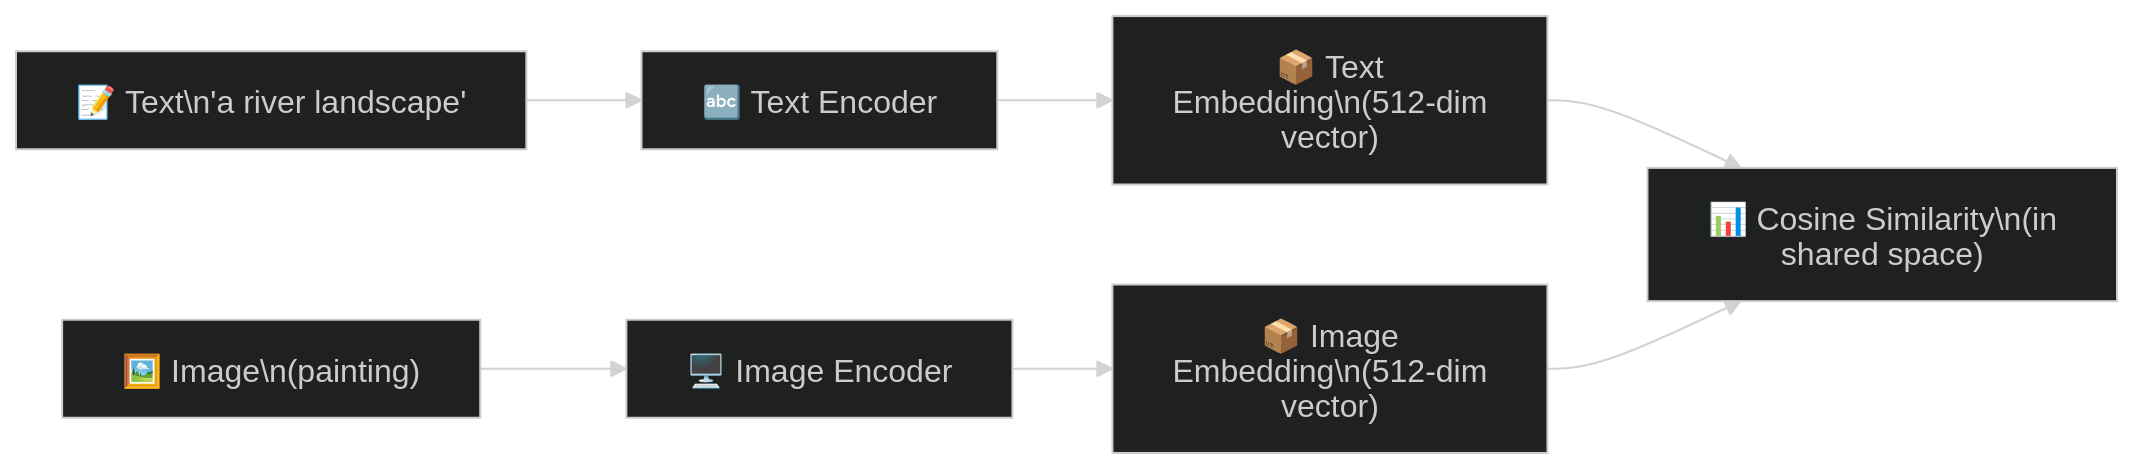


## What is a CLIP embedding?

In [ ]:

"""
                    768 dimensions →
        ┌───────────────────────────────────────────────┐
Token 1 │  0.12  -0.77   0.03   0.91  ...  -0.44  0.08 │
Token 2 │ -0.51   0.66  -0.09   0.24  ...   0.73 -0.19 │
Token 3 │  0.88  -0.11   0.47  -0.62  ...  -0.05  0.39 │
  ...   │   ...    ...    ...    ...  ...    ...   ... │
Token76 │ -0.34   0.92  -0.15   0.07  ...   0.58 -0.81 │
Token77 │  0.49  -0.28   0.63  -0.44  ...  -0.12  0.95 │
        └───────────────────────────────────────────────┘
                    ↑
                  77 tokens
""";

#### the content of a clip embedding visualized...
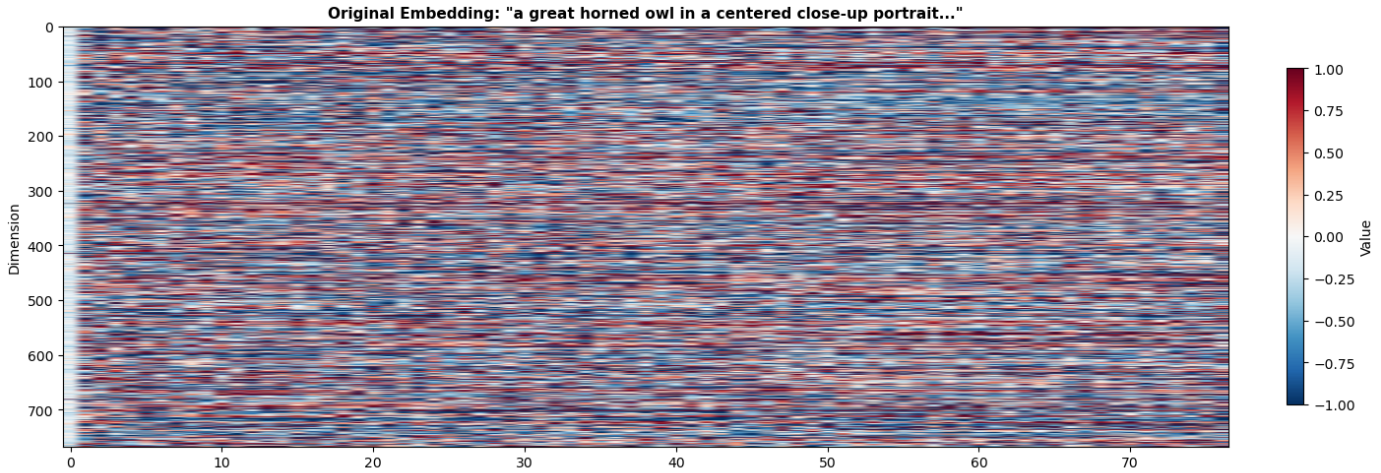

## Load the CLIP Model

The model weights (~350 MB for ViT-B/32) are downloaded on the first run and cached in `models/CLIP/` — subsequent runs load instantly from disk.

| Model | Dimensions | Speed | Quality |
|-------|-----------|-------|---------|
| `RN50` | 1024 | Fast | Good |
| `ViT-B/32` | 512 | Fast | Good ✓ |
| `ViT-B/16` | 512 | Medium | Better |
| `ViT-L/14` | 768 | Slow | Best |

In [ ]:
if CLIP_AVAILABLE:
    print(f"Loading CLIP model '{MODEL_NAME}'...")
    print(f'  Cache: {MODELS_DIR}')
    model, preprocess = clip.load(MODEL_NAME, device=DEVICE, download_root=str(MODELS_DIR))
    model.eval()
    print(f'✓ Model ready on {DEVICE}')
else:
    print('❌ CLIP not available — install it first (see install cell at the top)')

Loading CLIP model 'ViT-B/32'...
  Cache: drive/MyDrive/Distant_viewing/models/CLIP
✓ Model ready on cuda


## Compute Image Embeddings

An **embedding** is a 512-number vector encoding the meaning of an image. We process all downloaded images in batches, normalize each embedding to unit length, and save everything to a `.npz` file — so we never have to recompute.

```
Image → resize & normalize → CLIP image encoder → 512-dim vector → save to .npz
```

In [ ]:
# @title
import ipywidgets as widgets
from IPython.display import display, clear_output

BATCH_SIZE = 32  # reduce to 8 if you run out of GPU memory

# ── discover image folders ─────────────────────────────────────────────────────
_images_root   = DATA_DIR / 'images'
_image_folders = sorted(
    d.name for d in _images_root.iterdir()
    if d.is_dir() and any(d.glob('*'))
) if _images_root.exists() else []

_default_folder = _folder_name if _folder_name in _image_folders else (
    _image_folders[0] if _image_folders else None
)

if not _image_folders:
    print('⚠️  No image folders found in', _images_root)
    print('   Run Section 2 first to download images.')
else:
    _folder_dropdown = widgets.Dropdown(
        options=_image_folders,
        value=_default_folder,
        description='Image folder:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px'),
    )
    _run_button = widgets.Button(
        description='Compute Embeddings',
        button_style='primary',
        layout=widgets.Layout(width='200px'),
    )
    _emb_output = widgets.Output()

    def _on_compute(b):
        with _emb_output:
            clear_output(wait=True)
            if not CLIP_AVAILABLE:
                print('❌ CLIP not available')
                return

            sel_folder   = _folder_dropdown.value
            sel_imgs_dir = DATA_DIR / 'images'     / sel_folder
            sel_emb_file = DATA_DIR / 'embeddings' / sel_folder / f'{sel_folder}_clip_embeddings.npz'
            sel_emb_file.parent.mkdir(parents=True, exist_ok=True)

            image_files = sorted(
                f for f in sel_imgs_dir.glob('*')
                if f.suffix.lower() in ('.jpg', '.jpeg', '.png', '.webp')
            )

            if not image_files:
                print(f'⚠️ No images found in {sel_imgs_dir}')
                print('   Run Section 2 first to download images.')
                return

            if sel_emb_file.exists():
                print(f'ℹ️  Existing embeddings file found — recomputing and replacing.')

            print(f'Computing embeddings for {len(image_files)} images...')
            print(f'  Folder: {sel_folder}/')
            print(f'  Model: {MODEL_NAME}  |  Device: {DEVICE}  |  Batch: {BATCH_SIZE}\n')

            all_embeddings, all_filenames, failed = [], [], []
            t0 = time.time()

            for i in range(0, len(image_files), BATCH_SIZE):
                batch_files   = image_files[i : i + BATCH_SIZE]
                batch_tensors, batch_names = [], []

                for img_path in batch_files:
                    try:
                        img = PILImage.open(img_path).convert('RGB')
                        batch_tensors.append(preprocess(img))
                        batch_names.append(img_path.name)
                    except Exception as e:
                        failed.append((img_path.name, str(e)))

                if batch_tensors:
                    with torch.no_grad():
                        batch = torch.stack(batch_tensors).to(DEVICE)
                        emb   = model.encode_image(batch).float()
                        emb   = emb / emb.norm(dim=-1, keepdim=True)
                    all_embeddings.append(emb.cpu().numpy())
                    all_filenames.extend(batch_names)

                done = min(i + BATCH_SIZE, len(image_files))
                if done % (BATCH_SIZE * 5) == 0 or done == len(image_files):
                    elapsed = time.time() - t0
                    print(f'  {done:>5}/{len(image_files)}  ({done/elapsed:.0f} img/s)')

            embeddings_array = np.vstack(all_embeddings)

            np.savez_compressed(
                sel_emb_file,
                embeddings=embeddings_array,
                filenames=np.array(all_filenames, dtype=object),
                model_name=MODEL_NAME,
                embedding_dim=embeddings_array.shape[1],
            )

            # Update module-level path variables so the next cell loads the right file
            global COLLECTION_IMAGES_DIR, COLLECTION_EMBEDDINGS_FILE
            COLLECTION_IMAGES_DIR      = sel_imgs_dir
            COLLECTION_EMBEDDINGS_FILE = sel_emb_file

            elapsed = time.time() - t0
            if failed:
                print(f'  ⚠️ {len(failed)} images failed to process')
            print(f'\n✓ Saved {len(all_filenames)} embeddings in {elapsed:.0f}s')
            print(f'  Shape: {embeddings_array.shape}')
            print(f'  File:  {sel_emb_file}')

    _run_button.on_click(_on_compute)
    display(widgets.HBox([_folder_dropdown, _run_button]), _emb_output)


Output()

### Load Embeddings

In [ ]:
# @title
import ipywidgets as widgets
from IPython.display import display, clear_output

# ── discover available embeddings ──────────────────────────────────────────────
_emb_root = DATA_DIR / 'embeddings'
_emb_folders = sorted(
    d.name for d in _emb_root.iterdir()
    if d.is_dir() and any(d.glob('*.npz'))
) if _emb_root.exists() else []

_default_emb = COLLECTION_EMBEDDINGS_FILE.parent.name if COLLECTION_EMBEDDINGS_FILE.parent.name in _emb_folders else (
    _emb_folders[0] if _emb_folders else None
)

if not _emb_folders:
    print('⚠️  No embeddings found in', _emb_root)
    print('   Run the Compute Embeddings cell above first.')
    image_embeddings = None
    image_filenames  = None
else:
    _emb_dropdown = widgets.Dropdown(
        options=_emb_folders,
        value=_default_emb,
        description='Embeddings:',
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='500px'),
    )
    _load_button = widgets.Button(
        description='Load Embeddings',
        button_style='primary',
        layout=widgets.Layout(width='200px'),
    )
    _load_output = widgets.Output()

    def _on_load(b):
        with _load_output:
            clear_output(wait=True)
            sel_folder   = _emb_dropdown.value
            sel_emb_file = DATA_DIR / 'embeddings' / sel_folder / f'{sel_folder}_clip_embeddings.npz'

            if not sel_emb_file.exists():
                print(f'⚠️ File not found: {sel_emb_file}')
                print('   Run the Compute Embeddings cell above first.')
                return

            data = np.load(sel_emb_file, allow_pickle=True)
            emb_array   = data['embeddings']
            filenames   = data['filenames']
            saved_model = str(data.get('model_name', 'unknown'))

            print(f'✓ Loaded {len(filenames)} embeddings')
            print(f'  Shape: {emb_array.shape}  |  Model: {saved_model}')
            print(f'  File:  {sel_emb_file}')

            # Update module-level variables used by search cells
            global image_embeddings, image_filenames, COLLECTION_EMBEDDINGS_FILE, COLLECTION_IMAGES_DIR
            COLLECTION_IMAGES_DIR      = DATA_DIR / 'images'     / sel_folder
            COLLECTION_EMBEDDINGS_FILE = sel_emb_file
            image_filenames            = filenames

            if CLIP_AVAILABLE:
                image_embeddings = torch.tensor(emb_array, dtype=torch.float32).to(DEVICE)
            else:
                image_embeddings = emb_array

    _load_button.on_click(_on_load)
    display(widgets.HBox([_emb_dropdown, _load_button]), _load_output)


Output()

## Search with Natural Language

### How It Works

1. **Encode the query** — CLIP's text encoder turns your sentence into a 512-dim vector
2. **Dot product** — compare it against every image vector
3. **Rank by similarity** — images pointing in the same direction score highest

Because all embeddings are normalized to length 1, the dot product equals **cosine similarity**:

| Score | Meaning |
|-------|---------|
| **≈ 1.0** | Very similar |
| **≈ 0.0** | Unrelated |
| **≈ −1.0** | Opposite |



In [ ]:
# @title
def encode_text(text_query):
    """Convert a text string into a normalised CLIP embedding."""
    with torch.no_grad():
        tokens = clip.tokenize([text_query]).to(DEVICE)
        emb    = model.encode_text(tokens).float()
        emb    = emb / emb.norm(dim=-1, keepdim=True)
    return emb


def encode_text_ensemble(queries):
    """Encode multiple queries and return their mean embedding."""
    with torch.no_grad():
        tokens = clip.tokenize(queries).to(DEVICE)
        embs   = model.encode_text(tokens).float()
        mean   = embs.mean(dim=0, keepdim=True)
        mean   = mean / mean.norm(dim=-1, keepdim=True)
    return mean


_emb_cache = {}

def load_collection_embeddings(collection_name):
    """Load and cache embeddings for a named collection."""
    if collection_name in _emb_cache:
        return _emb_cache[collection_name]
    npz_files = list((DATA_DIR / 'embeddings' / collection_name).glob('*.npz'))
    if not npz_files:
        return None, None
    data = np.load(npz_files[0], allow_pickle=True)
    emb  = torch.from_numpy(data['embeddings']).float().to(DEVICE)
    emb  = emb / emb.norm(dim=-1, keepdim=True)
    _emb_cache[collection_name] = (emb, data['filenames'])
    return emb, data['filenames']


def semantic_search(query, top_k=10, use_ensemble=True, embeddings=None, filenames=None):
    """
    Search a collection with a natural-language query.

    Parameters:
        query:        Search string
        top_k:        Number of results to return
        use_ensemble: Expand query into multiple phrasings for robustness
        embeddings:   Embedding tensor to search (defaults to globally loaded embeddings)
        filenames:    Filename array matching embeddings (defaults to global)

    Returns:
        List of (filename, similarity_score) tuples, highest score first
    """
    emb = embeddings if embeddings is not None else image_embeddings
    fns = filenames  if filenames  is not None else image_filenames
    if emb is None:
        print('❌ No embeddings loaded — run the load cell or select a collection')
        return []

    if use_ensemble:
        text_emb = encode_text_ensemble([
            query,
            f'a painting of {query}',
            f'an artwork showing {query}',
            f'{query} in art',
        ])
    else:
        text_emb = encode_text(query)

    similarities = (emb @ text_emb.T).squeeze()
    top_indices  = similarities.argsort(descending=True)[:top_k]

    return [
        (str(fns[i.item()]), similarities[i].item())
        for i in top_indices
    ]


def display_results(results, collection_name=None, max_display=5):
    """Display top search results as inline images with similarity scores."""
    img_dir = (DATA_DIR / 'images' / collection_name) if collection_name else COLLECTION_IMAGES_DIR
    shown = 0
    for filename, score in results[:max_display]:
        img_path = img_dir / Path(filename).name
        print(f'\nScore: {score:.4f}  |  {Path(filename).name[:60]}')
        if img_path.exists():
            try:
                img   = PILImage.open(img_path)
                ratio = min(400 / img.width, 400 / img.height)
                if ratio < 1:
                    img = img.resize(
                        (int(img.width * ratio), int(img.height * ratio)),
                        PILImage.Resampling.LANCZOS
                    )
                display(img)
                shown += 1
            except Exception as e:
                print(f'  [Could not display: {e}]')
        else:
            print('  [Image not found locally — run Section 2 first]')

    if shown == 0:
        print('\n⚠️ No images displayed. Make sure Section 2 download has been run.')


print('✓ Search functions ready')

✓ Search functions ready


### Exercise: Search by Natural Language

Change `SEARCH_QUERY` and run the cell. Longer, more descriptive queries usually work better — CLIP was trained on image captions, not single keywords.

In [ ]:
# ============================================================
# EXERCISE: Change the query and run!
# ============================================================
SEARCH_QUERY = 'a beetle'
TOP_K        = 10
# ============================================================

In [ ]:
# @title
from IPython.display import clear_output

# Discover available collections from the embeddings folder
_emb_dir  = DATA_DIR / 'embeddings'
_text_cols = sorted([
    d.name for d in _emb_dir.iterdir()
    if d.is_dir() and any(d.glob('*.npz'))
]) if _emb_dir.exists() else []



_default_col = _folder_name if _folder_name in _text_cols else (_text_cols[0] if _text_cols else None)

text_collection_dropdown = widgets.Dropdown(
    options=_text_cols,
    value=_default_col,
    description='Collection:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px'),
)

_text_output = widgets.Output()
results_text = []  # accessible by the save cell below

def run_text_search(btn=None):
    global results_text
    with _text_output:
        clear_output(wait=True)
        selected = text_collection_dropdown.value
        if not selected:
            print('⚠️ No collections found — run Section 2 first.')
            return
        if not CLIP_AVAILABLE:
            print('❌ CLIP not available')
            return

        emb, fns = load_collection_embeddings(selected)
        if emb is None:
            print(f'❌ Embeddings not found for "{selected}" — compute them in Section 3 first.')
            return

        print(f"🔍 '{SEARCH_QUERY}'  in  '{selected}'")
        print('=' * 50)

        results_text = semantic_search(SEARCH_QUERY, top_k=TOP_K, use_ensemble=True,
                                       embeddings=emb, filenames=fns)

        for i, (filename, score) in enumerate(results_text, 1):
            print(f'{i:2}. {score:.4f}  {Path(filename).name[:55]}')

        print(f"\n🖼️  Top results for '{SEARCH_QUERY}':")
        display_results(results_text, collection_name=selected, max_display=5)

_text_search_btn = widgets.Button(
    description='🔍 Search',
    button_style='primary',
    layout=widgets.Layout(width='150px'),
)
_text_search_btn.on_click(run_text_search)

display(widgets.HBox([text_collection_dropdown, _text_search_btn]))
display(_text_output)


Output()

---

# Section 4: CLIP Similarity - Image Similarity 🖼️

Use an image as the query — find museum artworks visually similar to any photo you provide.

## Text Search vs. Image Search

| | Text Search (Section 3) | Image Search (this section) |
|--|--------------------------|------------------------------|
| **Query** | `"a river landscape"` | 🖼️ any image file |
| **Encoded by** | CLIP text encoder | CLIP image encoder |
| **Finds** | images matching the description | images with similar visual content |
| **Use case** | explore by concept | "find more like this" |

Both use the same embedding space — the query just comes from a different encoder.

## Upload a Query Image

You can use any image as your query — a painting, a photograph, even a smartphone photo. CLIP encodes it into the same 512-dim space and finds the closest matches.

In [ ]:
upload = widgets.FileUpload(accept='image/*', multiple=False)
display(upload)
print("Click 'Upload', select an image file, then run the next cell.")

FileUpload(value={}, accept='image/*', description='Upload')

Click 'Upload', select an image file, then run the next cell.


In [ ]:
# @title
query_image = None

if upload.value:
    # Get the first (and likely only) key-value pair from the uploaded files dictionary.
    # The key is the filename, and the value is the file_info dictionary.
    filename, file_info = next(iter(upload.value.items()))

    # Use the filename obtained from the dictionary key directly.
    name        = filename
    img_bytes   = file_info['content']

    query_image = PILImage.open(io.BytesIO(img_bytes)).convert('RGB')
    w, h        = query_image.size
    print(f'✓ Loaded: {name}  ({w}×{h})')
    thumb = query_image.resize((300, int(300 * h / w)))
    display(thumb)
else:
    print('No file uploaded yet — upload an image above, then re-run this cell.')

In [ ]:
# @title
import ipywidgets as widgets
from IPython.display import display, clear_output

# Discover available collections from embeddings folder
EMBEDDINGS_DIR = DATA_DIR / 'embeddings'
available_collections = {}

if EMBEDDINGS_DIR.exists():
    for folder in sorted(EMBEDDINGS_DIR.iterdir()):
        if folder.is_dir():
            npz_files = list(folder.glob('*.npz'))
            if npz_files:
                available_collections[folder.name] = npz_files[0]

print(f'Found {len(available_collections)} collections with embeddings')
for name in available_collections:
    print(f'  • {name}')

# Collection dropdown (shared with text search dropdown above)
collection_dropdown = widgets.Dropdown(
    options=list(available_collections.keys()),
    value=list(available_collections.keys())[0] if available_collections else None,
    description='Collection:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)


def image_similarity_search(query_img, collection_name, top_k=10, exclude_self=True):
    """
    Find collection images most similar to a query image.

    Parameters:
        query_img:       PIL Image to use as the query
        collection_name: Name of collection to search in
        top_k:           Number of results to return
        exclude_self:    Skip near-identical matches (score > 0.9999)

    Returns:
        List of (filename, similarity_score) tuples
    """
    coll_embeddings, coll_filenames = load_collection_embeddings(collection_name)

    if coll_embeddings is None:
        print(f'❌ No embeddings for collection: {collection_name}')
        return []

    with torch.no_grad():
        tensor    = preprocess(query_img).unsqueeze(0).to(DEVICE)
        query_emb = model.encode_image(tensor).float()
        query_emb = query_emb / query_emb.norm(dim=-1, keepdim=True)

    sims    = (coll_embeddings @ query_emb.T).squeeze()
    results = []
    for idx in sims.argsort(descending=True):
        fname = str(coll_filenames[idx.item()])
        score = sims[idx].item()
        if exclude_self and score > 0.9999:
            continue
        results.append((fname, score))
        if len(results) >= top_k:
            break
    return results


print('✓ Search functions ready')
display(collection_dropdown)

Found 2 collections with embeddings
  • Malmö_Museum_Portrait
  • Museum_of_Gothenburg
✓ Search functions ready


Dropdown(description='Collection:', layout=Layout(width='400px'), options=('Malmö_Museum_Portrait', 'Museum_o…

## Find Similar Artworks

In [ ]:
# @title
# Output area for results
output = widgets.Output()

def run_search(btn=None):
    """Run similarity search with selected collection."""
    with output:
        clear_output(wait=True)

        selected_collection = collection_dropdown.value

        if not CLIP_AVAILABLE:
            print('❌ CLIP not available')
            return

        if query_image is None:
            print('❌ No query image — upload an image in the cell above first.')
            return

        print(f"🔍 Searching in '{selected_collection}'...")
        print('=' * 50)

        results = image_similarity_search(
            query_image,
            collection_name=selected_collection,
            top_k=10
        )

        if results:
            for i, (filename, score) in enumerate(results, 1):
                print(f'{i:2}. {score:.4f}  {Path(filename).name[:55]}')

            print(f"\n🖼️  Top matches from '{selected_collection}':")
            display_results(results, selected_collection, max_display=5)
        else:
            print('No results found.')

# Search button
search_button = widgets.Button(
    description='🔍 Search Collection',
    button_style='primary',
    layout=widgets.Layout(width='200px')
)
search_button.on_click(run_search)

# Display controls
controls = widgets.HBox([collection_dropdown, search_button])
display(controls)
display(output)

# Auto-run if image is already uploaded
if query_image is not None:
    run_search()


Output()

### Useful Resources

- **Europeana Portal**: https://www.europeana.eu/
- **API Documentation**: https://pro.europeana.eu/page/apis
- **Get API Key**: https://pro.europeana.eu/page/get-api
- **IIIF**: https://iiif.io/
- **CLIP paper**: https://arxiv.org/abs/2103.00020